# Supply Chain Performance Analytics

## Objective
The objective of this project is to demonstrate how exploratory data analysis (EDA) using Python can identify operational inefficiencies and support business decision-making in a supply chain. It is not intended to build predictive or optimization models.

--- 
### Business Questions Addressed:
1. **Which product categories generate the most revenue?**
2. **Which products are loss-making?**
3. **Which suppliers have the highest defect rates?**
4. **Which shipping carrier is most cost-efficient?**
5. **Which suppliers have the longest manufacturing lead times?**

## Step 1: Data Loading & Cleaning

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset using relative path
DATA_PATH = os.path.join('data', 'supply_chain_data.csv')
df = pd.read_csv(DATA_PATH)

# Standardize column names to snake_case
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Display dataset summary
print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print("\nNull counts per column:")
print(df.isnull().sum())
df.head(3)

Dataset Shape: 100 rows × 24 columns
Duplicate Rows: 0

Null counts per column:
product_type               0
sku                        0
price                      0
availability               0
number_of_products_sold    0
revenue_generated          0
customer_demographics      0
stock_levels               0
lead_times                 0
order_quantities           0
shipping_times             0
shipping_carriers          0
shipping_costs             0
supplier_name              0
location                   0
lead_time                  0
production_volumes         0
manufacturing_lead_time    0
manufacturing_costs        0
inspection_results         0
defect_rates               0
transportation_modes       0
routes                     0
costs                      0
dtype: int64


,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282


## Step 2: Feature Engineering

We calculate **Unit Gross Profit** defined as:
$$\text{Unit Gross Profit} = \text{Selling Price} - \text{Manufacturing Cost}$$

This measures product-level profitability before logistics or overhead expenses.

In [2]:
# Calculate Unit Gross Profit
df['unit_gross_profit'] = df['price'] - df['manufacturing_costs']

profitable_count = (df['unit_gross_profit'] >= 0).sum()
loss_count = (df['unit_gross_profit'] < 0).sum()

print(f"Profitable SKUs: {profitable_count} | Loss-making SKUs: {loss_count}")
print(f"Average Unit Gross Profit: ${df['unit_gross_profit'].mean():.2f}")
df[['sku', 'product_type', 'price', 'manufacturing_costs', 'unit_gross_profit']].head()

Profitable SKUs: 56 | Loss-making SKUs: 44
Average Unit Gross Profit: $2.20


,sku,product_type,price,manufacturing_costs,unit_gross_profit
0,SKU0,haircare,69.808006,46.279879,23.528126
1,SKU1,skincare,14.843523,33.616769,-18.773246
2,SKU2,haircare,11.319683,30.688019,-19.368336
3,SKU3,skincare,61.163343,35.624741,25.538602
4,SKU4,skincare,4.805496,92.065161,-87.259665


## Step 3: Exploratory Analysis & Business Questions

In [3]:
# Q1: Revenue Analysis
revenue_by_category = (
    df.groupby('product_type')['revenue_generated']
    .agg(['sum', 'mean', 'count'])
    .rename(columns={'sum': 'total_revenue', 'mean': 'avg_revenue', 'count': 'sku_count'})
    .sort_values('total_revenue', ascending=False)
)
print("--- Revenue by Category ---")
print(revenue_by_category)

print("\n--- Top 10 SKUs by Revenue ---")
top10_revenue = df.nlargest(10, 'revenue_generated')[['sku', 'product_type', 'revenue_generated']]
print(top10_revenue.to_string(index=False))

# Q2: Product Profitability
print("\n--- Average Unit Gross Profit by Category ---")
print(df.groupby('product_type')['unit_gross_profit'].mean())

print("\n--- Top 5 Profitable SKUs ---")
print(df.nlargest(5, 'unit_gross_profit')[['sku', 'product_type', 'price', 'manufacturing_costs', 'unit_gross_profit']].to_string(index=False))

print("\n--- Bottom 5 Loss-making SKUs ---")
print(df.nsmallest(5, 'unit_gross_profit')[['sku', 'product_type', 'price', 'manufacturing_costs', 'unit_gross_profit']].to_string(index=False))

# Q3: Supplier Defect Rates
print("\n--- Defect Rate by Supplier ---")
print(df.groupby('supplier_name')['defect_rates'].mean().sort_values(ascending=False))

# Q4: Carrier Shipping Costs
print("\n--- Shipping Cost by Carrier ---")
print(df.groupby('shipping_carriers')['shipping_costs'].agg(['mean', 'min', 'max']).sort_values('mean'))

# Q5: Supplier Manufacturing Lead Times
print("\n--- Manufacturing Lead Time by Supplier ---")
print(df.groupby('supplier_name')['manufacturing_lead_time'].mean().sort_values(ascending=False))

--- Revenue by Category ---
              total_revenue  avg_revenue  sku_count
product_type                                       
skincare      241628.162133  6040.704053         40
haircare      174455.390605  5131.040900         34
cosmetics     161521.265999  6212.356385         26

--- Top 10 SKUs by Revenue ---
  sku product_type  revenue_generated
SKU51     haircare        9866.465458
SKU38    cosmetics        9692.318040
SKU31     skincare        9655.135103
SKU90     skincare        9592.633570
 SKU2     haircare        9577.749626
SKU32     skincare        9571.550487
SKU67     skincare        9473.798033
SKU88    cosmetics        9444.742033
SKU52     skincare        9435.762609
SKU18     haircare        9364.673505

--- Average Unit Gross Profit by Category ---
product_type
cosmetics    14.308317
haircare     -2.443715
skincare     -1.733828
Name: unit_gross_profit, dtype: float64

--- Top 5 Profitable SKUs ---
  sku product_type     price  manufacturing_costs  unit_gross_

## Step 4: Visualizations

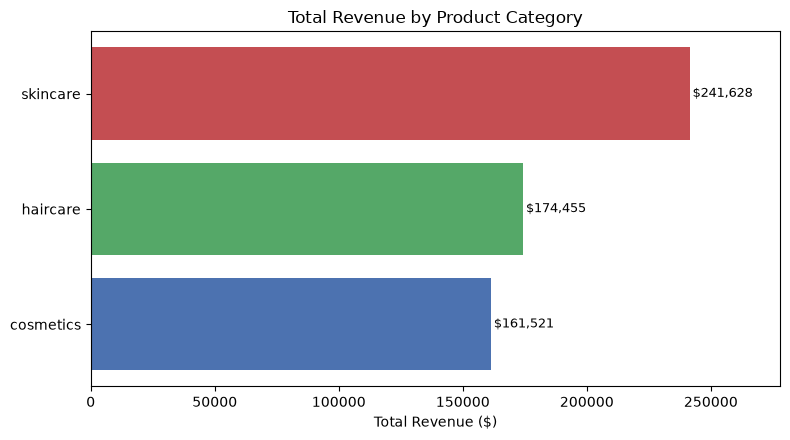

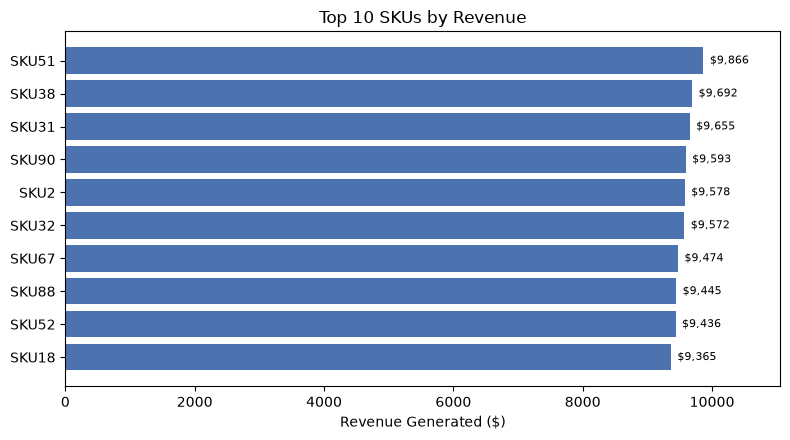

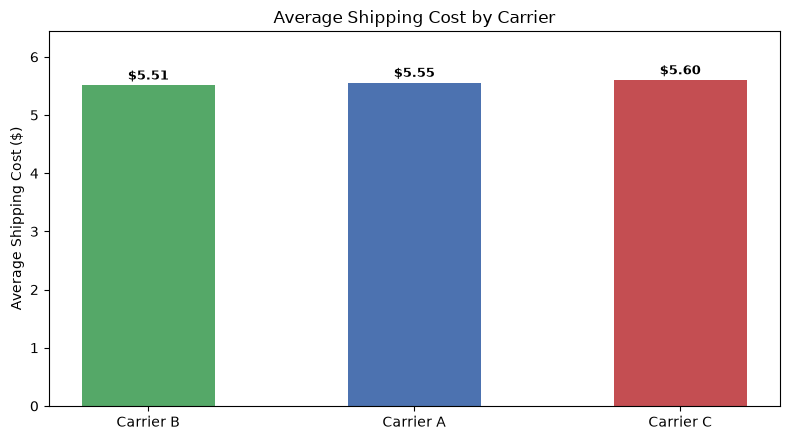

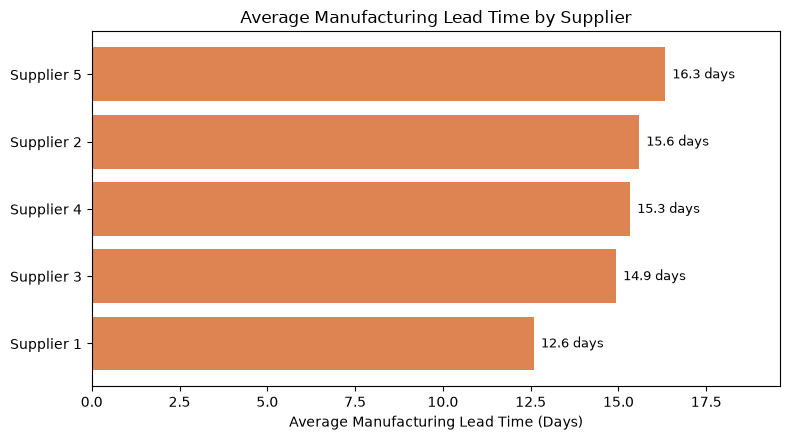

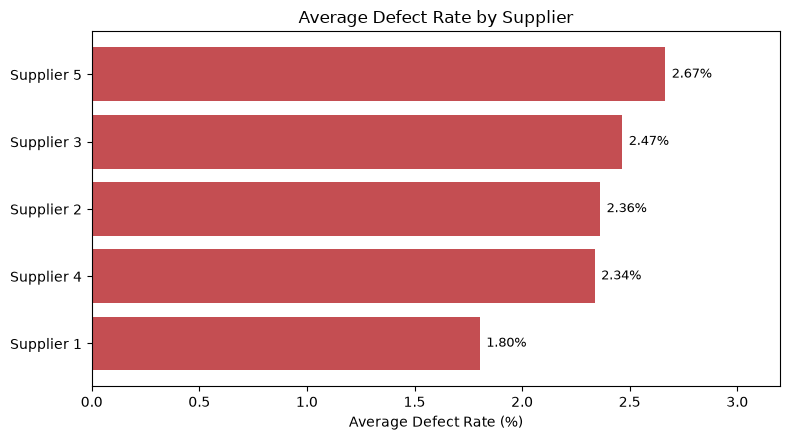

In [4]:
%matplotlib inline
plt.rcParams.update({'figure.figsize': (8, 4.5), 'axes.titlesize': 12, 'axes.labelsize': 10})

# 1. Revenue by Product Category
data = revenue_by_category['total_revenue'].sort_values()
fig, ax = plt.subplots()
bars = ax.barh(data.index, data.values, color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_xlabel('Total Revenue ($)')
ax.set_title('Total Revenue by Product Category')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 1000, bar.get_y() + bar.get_height()/2, f'${w:,.0f}', va='center', fontsize=9)
ax.set_xlim(0, data.max() * 1.15)
plt.tight_layout()
plt.show()

# 2. Top 10 SKUs by Revenue
data_top10 = top10_revenue.sort_values('revenue_generated')
fig, ax = plt.subplots()
bars = ax.barh(data_top10['sku'], data_top10['revenue_generated'], color='#4C72B0')
ax.set_xlabel('Revenue Generated ($)')
ax.set_title('Top 10 SKUs by Revenue')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 100, bar.get_y() + bar.get_height()/2, f'${w:,.0f}', va='center', fontsize=8)
ax.set_xlim(0, data_top10['revenue_generated'].max() * 1.12)
plt.tight_layout()
plt.show()

# 3. Shipping Cost by Carrier
carrier_avg = df.groupby('shipping_carriers')['shipping_costs'].mean().sort_values()
fig, ax = plt.subplots()
bars = ax.bar(carrier_avg.index, carrier_avg.values, color=['#55A868', '#4C72B0', '#C44E52'], width=0.5)
ax.set_ylabel('Average Shipping Cost ($)')
ax.set_title('Average Shipping Cost by Carrier')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.05, f'${h:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylim(0, carrier_avg.max() * 1.15)
plt.tight_layout()
plt.show()

# 4. Manufacturing Lead Time by Supplier
lead_avg = df.groupby('supplier_name')['manufacturing_lead_time'].mean().sort_values()
fig, ax = plt.subplots()
bars = ax.barh(lead_avg.index, lead_avg.values, color='#DD8452')
ax.set_xlabel('Average Manufacturing Lead Time (Days)')
ax.set_title('Average Manufacturing Lead Time by Supplier')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.2, bar.get_y() + bar.get_height()/2, f'{w:.1f} days', va='center', fontsize=9)
ax.set_xlim(0, lead_avg.max() * 1.2)
plt.tight_layout()
plt.show()

# 5. Defect Rate by Supplier
defect_avg = df.groupby('supplier_name')['defect_rates'].mean().sort_values()
fig, ax = plt.subplots()
bars = ax.barh(defect_avg.index, defect_avg.values, color='#C44E52')
ax.set_xlabel('Average Defect Rate (%)')
ax.set_title('Average Defect Rate by Supplier')
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.03, bar.get_y() + bar.get_height()/2, f'{w:.2f}%', va='center', fontsize=9)
ax.set_xlim(0, defect_avg.max() * 1.2)
plt.tight_layout()
plt.show()

## Step 5: Summary & Key Recommendations

1. **Product Profitability**: Review pricing and manufacturing costs for the **44 loss-making SKUs** (e.g., SKU23 losing $94.29/unit). Consider price adjustments or SKU discontinuation.
2. **Supplier Management**: Allocate more production to **Supplier 1** (lowest defect rate at 1.80%, fastest lead time at 12.6 days). Conduct quality audits for **Supplier 5** (highest defect rate at 2.67%, slowest lead time at 16.3 days).
3. **Category Strategy**: Expand the cosmetics portfolio to leverage its high per-SKU profitability (+ $14.31 avg unit gross profit) while continuing to scale skincare revenue.